In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [2]:
data_path = "../Data/creditcard.csv"

df = pd.read_csv(data_path)

In [3]:
X = df.drop("Class", axis=1)

y = df["Class"]

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [5]:
scaler = StandardScaler()

X_train[["Time", "Amount"]] = scaler.fit_transform(
    X_train[["Time", "Amount"]]
)

X_test[["Time", "Amount"]] = scaler.transform(
    X_test[["Time", "Amount"]]
)

In [6]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

In [7]:
rf_model.fit(X_train, y_train)

print("Random Forest Training Completed")

Random Forest Training Completed


In [8]:
y_pred_rf = rf_model.predict(X_test)

In [9]:
print("Accuracy :", accuracy_score(y_test, y_pred_rf))

print("Precision:", precision_score(y_test, y_pred_rf))

print("Recall   :", recall_score(y_test, y_pred_rf))

print("F1 Score :", f1_score(y_test, y_pred_rf))

Accuracy : 0.9995962220427653
Precision: 0.9411764705882353
Recall   : 0.8163265306122449
F1 Score : 0.8743169398907104


In [10]:
print("\nClassification Report:\n")

print(classification_report(y_test, y_pred_rf))


Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.94      0.82      0.87        98

    accuracy                           1.00     56962
   macro avg       0.97      0.91      0.94     56962
weighted avg       1.00      1.00      1.00     56962



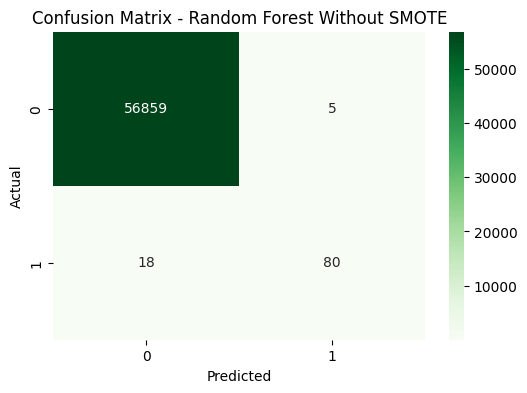

In [11]:
plt.figure(figsize=(6,4))

sns.heatmap(
    confusion_matrix(y_test, y_pred_rf),
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title("Confusion Matrix - Random Forest Without SMOTE")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# 🌲 Random Forest Analysis (Without SMOTE)

---

# 🧠 Why Random Forest Was Used

Random Forest is an ensemble Machine Learning algorithm that combines multiple decision trees to improve prediction performance.

Unlike Logistic Regression, Random Forest can:

* capture nonlinear relationships
* handle complex feature interactions
* reduce overfitting using ensemble averaging
* work effectively on structured tabular datasets
* naturally perform better on many classification problems

Fraud detection datasets often contain highly complex transaction patterns, making Random Forest a strong candidate for comparison against Logistic Regression.

---

# ⚙️ How Random Forest Works

Random Forest creates multiple decision trees using random subsets of:

* training samples
* feature columns

Each tree independently predicts whether a transaction is fraud or non-fraud.

The final prediction is determined using:

# 🗳️ Majority Voting

If most trees classify a transaction as fraud, the final output becomes fraud.

This ensemble approach improves:

* stability
* generalization
* robustness
* prediction performance

---

# 🧩 Random Forest Configuration Used

```python
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
```

### Parameter Explanation

| Parameter          | Meaning                                |
| ------------------ | -------------------------------------- |
| `n_estimators=100` | Builds 100 decision trees              |
| `random_state=42`  | Ensures reproducible results           |
| `n_jobs=-1`        | Uses all CPU cores for faster training |

---

# 📊 Random Forest Results (Without SMOTE)

| Metric       | Score  |
| ------------ | ------ |
| 🎯 Accuracy  | 99.96% |
| 🎯 Precision | 94.12% |
| 🔍 Recall    | 81.63% |
| ⚖️ F1 Score  | 87.43% |

---

# 🧠 Confusion Matrix Interpretation

| Actual / Predicted | Non-Fraud | Fraud |
| ------------------ | --------: | ----: |
| Non-Fraud          |     56859 |     5 |
| Fraud              |        18 |    80 |

---

# 📌 Important Observations

| Metric             | Value |
| ------------------ | ----: |
| ✅ True Positives   |    80 |
| ✅ True Negatives   | 56859 |
| ⚠️ False Positives |     5 |
| ❌ False Negatives  |    18 |

---

# 🎯 Accuracy = 99.96%

The Random Forest model achieved extremely high accuracy.

Compared to Logistic Regression without SMOTE:

| Model                             | Accuracy |
| --------------------------------- | -------: |
| Logistic Regression Without SMOTE |   99.91% |
| Random Forest Without SMOTE       |   99.96% |

This indicates Random Forest handled the dataset structure more effectively.

---

# 🎯 Precision = 94.12%

Precision improved significantly.

| Model                             | Precision |
| --------------------------------- | --------: |
| Logistic Regression Without SMOTE |    82.89% |
| Random Forest Without SMOTE       |    94.12% |

This means:

# 🚨 Very Few False Fraud Alerts

From the confusion matrix:

| Model                             | False Positives |
| --------------------------------- | --------------: |
| Logistic Regression Without SMOTE |              13 |
| Random Forest Without SMOTE       |               5 |

The Random Forest model was much more reliable when predicting fraud.

---

# 🔍 Recall = 81.63%

Recall also improved strongly.

| Model                             | Recall |
| --------------------------------- | -----: |
| Logistic Regression Without SMOTE | 64.29% |
| Random Forest Without SMOTE       | 81.63% |

This means the Random Forest model successfully detected more actual fraud transactions.

False Negatives reduced from:

```text
35 → 18
```

which is a major improvement in fraud detection capability.

---

# ⚖️ F1 Score = 87.43%

F1 Score improved significantly.

| Model                             | F1 Score |
| --------------------------------- | -------: |
| Logistic Regression Without SMOTE |   72.41% |
| Random Forest Without SMOTE       |   87.43% |

This indicates a much stronger balance between:

* fraud detection capability
* false alarm control

---

# 🔥 Comparative Analysis Across Models

| Metric          | Logistic Regression Without SMOTE | Logistic Regression With SMOTE | Random Forest Without SMOTE |
| --------------- | --------------------------------: | -----------------------------: | --------------------------: |
| Accuracy        |                            99.91% |                         97.42% |                      99.96% |
| Precision       |                            82.89% |                          5.80% |                      94.12% |
| Recall          |                            64.29% |                         91.84% |                      81.63% |
| F1 Score        |                            72.41% |                         10.92% |                      87.43% |
| False Positives |                                13 |                           1461 |                           5 |
| False Negatives |                                35 |                              8 |                          18 |

---

# 🧠 Key Insights from the Comparison

## Logistic Regression Without SMOTE

* Very high accuracy
* Good precision
* Moderate fraud detection capability
* Missed many fraud cases

### Main Issue

The model remained biased toward the majority class.

---

## Logistic Regression With SMOTE

* Recall improved dramatically
* Fraud detection became highly sensitive
* False Negatives reduced heavily

### Major Tradeoff

False Positives increased massively:

```text
13 → 1461
```

This caused Precision and F1 Score to collapse.

The model became too aggressive in predicting fraud.

---

## Random Forest Without SMOTE

Random Forest achieved the strongest overall balance.

### Major Advantages

* Highest Precision
* Highest F1 Score
* Very high Recall
* Very low False Positives
* Reduced False Negatives

This suggests that:

# 🚀 Model selection itself can sometimes improve imbalance handling even before applying SMOTE.

---

# 🏦 Business Interpretation

Each model represents a different fraud detection strategy.

| Model Behavior      | Business Impact            |
| ------------------- | -------------------------- |
| High Recall         | Catch more fraud           |
| High Precision      | Reduce false alarms        |
| Low False Negatives | Better fraud protection    |
| Low False Positives | Better customer experience |

---

# ⚖️ Final Tradeoff Analysis

## Logistic Regression With SMOTE

### Strength

```text
Very high fraud detection sensitivity
```

### Weakness

```text
Extremely high false alarm rate
```

---

## Random Forest Without SMOTE

### Strength

```text
Strong balance between fraud detection and false alarm control
```

### Weakness

```text
Still misses some fraud transactions
```

---

# 🚀 Final Understanding

This experiment demonstrates that:

# Imbalanced classification performance depends not only on SMOTE, but also heavily on model selection.

The Random Forest model significantly outperformed Logistic Regression without requiring oversampling.

At the same time, SMOTE demonstrated how imbalance handling techniques can dramatically improve fraud detection sensitivity, but often at the cost of Precision.

This comparison highlights the core challenge in fraud detection systems:

# Maximizing fraud detection while minimizing false alarms.
